## Подбор архитектуры и гиперпараметров модели

### Что сделано:
1) Сравнивались модели `DummyRegressor`, `LinearRegression`, `RandomForestRegressor`, `CatBoostRegressor`
2) Для `RandomForestRegressor` подбирались гиперпараметры через GridSearchCV
3) Для всех моделей посчитаны метрики: MAE, RMSE, R^2, MAPE
4) Выбрана лучшая модель по RMSE на validaion

### Краткие выводы:
1) Лучшая модель - `CatBoostRegressor`
2) Метрики лучшей модели на test: 
    - `MAE` = 1182.15
    - `RMSE` = 2022.0
    - `R^2` = 0.9
    - `MAPE` = 36.27

### Полученные артефакты:
1) [`artifacts/experiments_log.json`](../artifacts//experiments_log.json) - Лог экспериментов по всем моделям, содержит их гиперпараметры и метрики
2) [`artifacts/true_vs_predicted.png`](../artifacts/true_vs_predicted.png) - График ошибок лучшей модели
3) [`artifacts/model.cbm`](../artifacts/model.cbm) - Лучшая модель
4) [`configs/model_config.json`](../configs/model_config.json) - Конфиг для обучения лучшей модели

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import random
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import json
import os
from pathlib import Path
from catboost import CatBoostRegressor, Pool
import matplotlib.pyplot as plt


DATASET_FILE_PATH = "../data/dataset_autos_full_prepared.csv"
EXPERIMENTS_FILE_PATH = "../artifacts/experiments_log.json"
RANDOM_STATE = 42


def set_seed(seed: int = RANDOM_STATE):
    np.random.seed(seed)
    random.seed(seed)

set_seed(RANDOM_STATE)

---
### Вспомогательные функции

In [3]:
def split_dataset(df: pd.DataFrame, 
                  splits: tuple = (0.7, 0.15, 0.15), 
                  random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame]:
    """
    Разбивает DataFrame на train/val/test
    """
    train_frac, val_frac, test_frac = splits
    
    test_size = test_frac / sum(splits)
    train_val_df, test_df = train_test_split(df, test_size=test_size, random_state=random_state)
    
    val_size = val_frac / (train_frac + val_frac)
    train_df, val_df = train_test_split(train_val_df, test_size=val_size, random_state=random_state)
    
    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True)
    )


def calculate_metrics(y_true: pd.Series, y_pred: np.ndarray, min_price: float = 100) -> dict:
    """
    Вычисляет метрики регрессии.
    min_price: игнорируем автомобили дешевле этой суммы при расчёте MAPE
    """
    
    metrics = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
    }
    
    # Безопасный MAPE: исключаем очень дешёвые авто
    mask = y_true >= min_price
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        metrics["MAPE"] = mape
    else:
        metrics["MAPE"] = np.nan
        
    return metrics


def print_metrics(metrics: dict, model_name: str = "Model"):
    """Красиво выводит метрики в консоль."""
    print(f"\n {model_name}")
    print("─" * 35)
    for name, value in metrics.items():
        print(f"{name:<6} | {value:.2f}")
    print("─" * 35)


def log_experiment(model, metrics, file_path=EXPERIMENTS_FILE_PATH):
    """
    Логировани результатов экспериментов в json-файл
    """
    path = Path(file_path).resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    
    model_name = model.__class__.__name__
    params = model.get_params() if hasattr(model, 'get_params') else {}
    
    clean_metrics = {k: (float(v) if hasattr(v, 'item') else v) for k, v in metrics.items()}
    
    new_entry = {
        "model_name": model_name,
        "params": params,
        "metrics": clean_metrics
    }
    
    data = []
    if path.exists() and path.stat().st_size > 0:
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
    # Обновление или добавление
    for i, entry in enumerate(data):
        if entry["model_name"] == model_name:
            data[i] = new_entry
            break
    else:
        data.append(new_entry)
        
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2, ensure_ascii=False)
    
    # Вывод таблицы
    df = pd.DataFrame(data)
    if 'metrics' in df.columns:
        df = df.drop(columns=['metrics']).join(pd.json_normalize(df['metrics']))
        
    display(df.style.format({
        "MAE": "{:.2f}", "RMSE": "{:.2f}", 
        "MAPE": "{:.2f}", "R²": "{:.3f}"
    }, na_rep="—"))

---
### Загрузка и разбиение данных

In [4]:
full_df = pd.read_csv(DATASET_FILE_PATH, encoding='utf-8')
train_df, val_df, test_df = split_dataset(full_df, splits=(0.7, 0.15, 0.15))

TARGET = "price"
FEATURES = [col for col in train_df.columns if col != TARGET]

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

# sanity-check
print("==== Features ====")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"==== Targets ====")
print(f"Train: {y_train.shape}, Val: {y_val.shape}, Test: {y_test.shape}")


==== Features ====
Train: (177837, 12), Val: (38109, 12), Test: (38109, 12)
==== Targets ====
Train: (177837,), Val: (38109,), Test: (38109,)


---
### 1. DummyRegressor (Baseline)

In [5]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)

val_preds_dummy = dummy.predict(X_val)
metrics_dummy = calculate_metrics(y_val, val_preds_dummy)

print_metrics(metrics_dummy, "DummyRegressor (median)")
log_experiment(dummy, metrics_dummy)


 DummyRegressor (median)
───────────────────────────────────
MAE    | 4407.16
RMSE   | 6856.59
r2     | -0.14
MAPE   | 150.98
───────────────────────────────────


,model_name,params,MAE,RMSE,r2,MAPE
0,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy': 'median'}",4407.16,6856.59,-0.136614,150.98
1,LinearRegression,"{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 1e-06}",2637.88,3748.52,0.660284,115.57
2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}",1171.61,2037.60,0.899623,36.18
3,CatBoostRegressor,"{'iterations': 1000, 'learning_rate': 0.03, 'depth': 8, 'loss_function': 'RMSE', 'random_seed': 42, 'use_best_model': True, 'verbose': 100, 'eval_metric': 'RMSE', 'early_stopping_rounds': 50}",1182.15,2022.00,0.901154,36.27


---
### 2. LinearRegression

In [6]:
linear_regression = LinearRegression(n_jobs=-1)
linear_regression.fit(X_train, y_train)

val_preds_lr = linear_regression.predict(X_val)
metrics_lr = calculate_metrics(y_val, val_preds_lr)

print_metrics(metrics_lr, "LinearRegression")
log_experiment(linear_regression, metrics_lr)


 LinearRegression
───────────────────────────────────
MAE    | 2637.88
RMSE   | 3748.52
r2     | 0.66
MAPE   | 115.57
───────────────────────────────────


,model_name,params,MAE,RMSE,r2,MAPE
0,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy': 'median'}",4407.16,6856.59,-0.136614,150.98
1,LinearRegression,"{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 1e-06}",2637.88,3748.52,0.660284,115.57
2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}",1171.61,2037.60,0.899623,36.18
3,CatBoostRegressor,"{'iterations': 1000, 'learning_rate': 0.03, 'depth': 8, 'loss_function': 'RMSE', 'random_seed': 42, 'use_best_model': True, 'verbose': 100, 'eval_metric': 'RMSE', 'early_stopping_rounds': 50}",1182.15,2022.00,0.901154,36.27


---
### 3. RandomForest

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'min_samples_leaf': [1, 5],
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error', # Оптимизируем по RMSE
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ................min_samples_leaf=1, n_estimators=50; total time=   4.2s
[CV] END ................min_samples_leaf=1, n_estimators=50; total time=   2.3s
[CV] END ................min_samples_leaf=1, n_estimators=50; total time=   2.2s
[CV] END ...............min_samples_leaf=1, n_estimators=100; total time=   4.3s
[CV] END ...............min_samples_leaf=1, n_estimators=100; total time=   4.5s
[CV] END ...............min_samples_leaf=1, n_estimators=100; total time=   4.5s
[CV] END ...............min_samples_leaf=1, n_estimators=200; total time=   8.9s
[CV] END ...............min_samples_leaf=1, n_estimators=200; total time=   8.8s
[CV] END ...............min_samples_leaf=1, n_estimators=200; total time=   8.8s
[CV] END ................min_samples_leaf=5, n_estimators=50; total time=   1.8s
[CV] END ................min_samples_leaf=5, n_estimators=50; total time=   1.8s
[CV] END ................min_samples_leaf=5, n_es

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_samples_leaf': [1, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [ ]:
best_rf = grid_search.best_estimator_

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший RMSE на кросс-валидации: {-grid_search.best_score_:.2f}")

val_preds_rf_grid = best_rf.predict(X_val)

metrics_rf_grid = calculate_metrics(y_val, val_preds_rf_grid)

print_metrics(metrics_rf_grid, "RandomForest (GridSearchCV)")
log_experiment(best_rf, metrics_rf_grid)


Лучшие параметры: {'min_samples_leaf': 1, 'n_estimators': 200}
Лучший RMSE на кросс-валидации: 2055.41

 RandomForest (GridSearchCV)
───────────────────────────────────
MAE    | 1171.61
RMSE   | 2037.60
r2     | 0.90
MAPE   | 36.18
───────────────────────────────────


,model_name,params,MAE,RMSE,r2,MAPE
0,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy': 'median'}",4407.16,6856.59,-0.136614,150.98
1,LinearRegression,"{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 1e-06}",2637.88,3748.52,0.660284,115.57
2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}",1171.61,2037.60,0.899623,36.18


---
### 5. CatBoost

In [7]:
train_pool = Pool(X_train, y_train)

val_pool = Pool(X_val, y_val)

catboost_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=RANDOM_STATE,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True
)

catboost_model.fit(
    train_pool,
    eval_set=val_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 6250.2953252	test: 6285.7589013	best: 6285.7589013 (0)	total: 64.4ms	remaining: 1m 4s
100:	learn: 2524.7396356	test: 2543.6870645	best: 2543.6870645 (100)	total: 652ms	remaining: 5.81s
200:	learn: 2264.0008056	test: 2303.8114305	best: 2303.8114305 (200)	total: 1.19s	remaining: 4.73s
300:	learn: 2155.9996328	test: 2209.8455185	best: 2209.8455185 (300)	total: 1.74s	remaining: 4.04s
400:	learn: 2087.6519116	test: 2153.6383145	best: 2153.6383145 (400)	total: 2.3s	remaining: 3.44s
500:	learn: 2035.5132057	test: 2112.0713827	best: 2112.0713827 (500)	total: 2.87s	remaining: 2.86s
600:	learn: 1998.5751058	test: 2084.8261535	best: 2084.8261535 (600)	total: 3.41s	remaining: 2.27s
700:	learn: 1967.5479317	test: 2063.0107665	best: 2063.0107665 (700)	total: 3.97s	remaining: 1.69s
800:	learn: 1943.2224710	test: 2047.6757806	best: 2047.6757806 (800)	total: 4.48s	remaining: 1.11s
900:	learn: 1920.0280297	test: 2033.3891298	best: 2033.3891298 (900)	total: 5s	remaining: 549ms
999:	learn: 1899.

CatBoostRegressor(depth=8, early_stopping_rounds=50, eval_metric='RMSE', iterations=1000, learning_rate=0.03, loss_function='RMSE', random_seed=42, use_best_model=True, verbose=100)

In [8]:
val_preds_cb = catboost_model.predict(val_pool)

metrics_cb = calculate_metrics(y_val, val_preds_cb)
print_metrics(metrics_cb, "CatBoostRegressor")

log_experiment(catboost_model, metrics_cb)


 CatBoostRegressor
───────────────────────────────────
MAE    | 1182.15
RMSE   | 2022.00
r2     | 0.90
MAPE   | 36.27
───────────────────────────────────


,model_name,params,MAE,RMSE,r2,MAPE
0,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy': 'median'}",4407.16,6856.59,-0.136614,150.98
1,LinearRegression,"{'copy_X': True, 'fit_intercept': True, 'n_jobs': -1, 'positive': False, 'tol': 1e-06}",2637.88,3748.52,0.660284,115.57
2,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}",1171.61,2037.60,0.899623,36.18
3,CatBoostRegressor,"{'iterations': 1000, 'learning_rate': 0.03, 'depth': 8, 'loss_function': 'RMSE', 'random_seed': 42, 'use_best_model': True, 'verbose': 100, 'eval_metric': 'RMSE', 'early_stopping_rounds': 50}",1182.15,2022.00,0.901154,36.27


---
### Финальное сравнение моделей

In [9]:
metric = 'RMSE'
with open(EXPERIMENTS_FILE_PATH, 'r', encoding='utf-8') as f:
    experiments = pd.DataFrame(json.load(f))

experiments = experiments.sort_values(
    by='metrics',
    key=lambda col: col.str.get(metric),
    ascending=True
).reset_index(drop=True)

display(experiments.drop(columns='metrics').join(pd.json_normalize(experiments['metrics'])))

best_model_name = experiments['model_name'][0]
print(f"Лучшая модель по {metric}: {best_model_name}")

,model_name,params,MAE,RMSE,r2,MAPE
0,CatBoostRegressor,"{'iterations': 1000, 'learning_rate': 0.03, 'd...",1182.153301,2021.996300,0.901154,36.269250
1,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",1171.607755,2037.598067,0.899623,36.177629
2,LinearRegression,"{'copy_X': True, 'fit_intercept': True, 'n_job...",2637.884662,3748.517854,0.660284,115.574401
3,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy...",4407.162035,6856.591212,-0.136614,150.982213


Лучшая модель по RMSE: CatBoostRegressor


---
### Финальная оценка на test

In [13]:
test_preds = catboost_model.predict(X_test)

test_metrics = calculate_metrics(y_test, test_preds)
print_metrics(test_metrics, "CatBoostRegressor (Test)")

# Сохраняем конфиг лучшей модели
MODEL_CONFIG_PATH = "../configs/model_config.json"
with open(MODEL_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(experiments.iloc[0].to_dict(), f, indent=2)
catboost_model.save_model("../artifacts/model.cbm", format="cbm")
print("Модель сохраненена в artifacts/model.cbm")


 CatBoostRegressor (Test)
───────────────────────────────────
MAE    | 1189.16
RMSE   | 2059.29
r2     | 0.90
MAPE   | 36.68
───────────────────────────────────
Модель сохраненена в artifacts/model.cbm


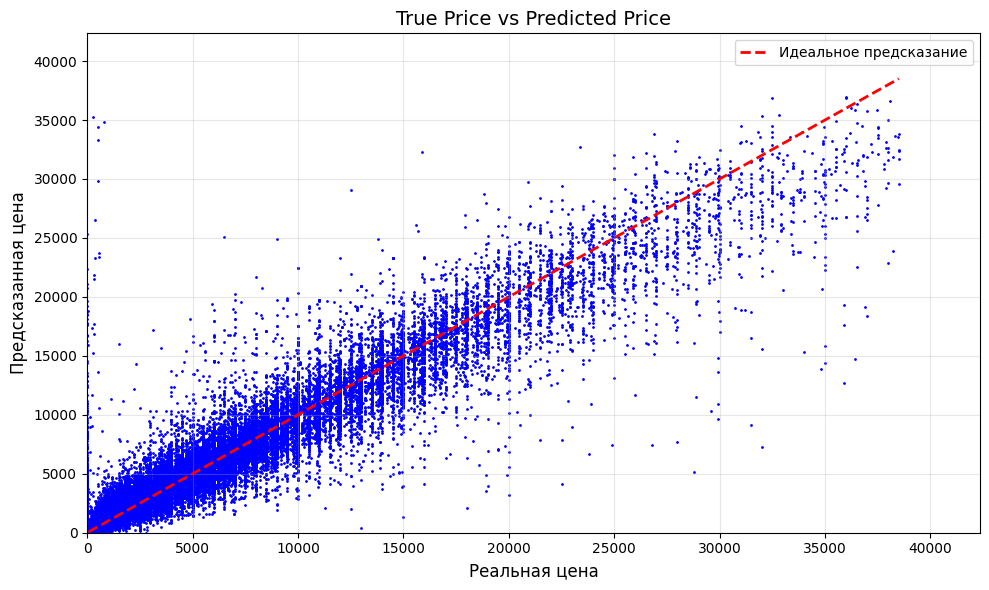

In [59]:
plt.figure(figsize=(10, 6))

plt.scatter(x=y_test, y=test_preds, alpha=1, s=1, color='blue')

# Идеальная линия (y=x)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Идеальное предсказание')

plt.title("True Price vs Predicted Price", fontsize=14)
plt.xlabel("Реальная цена", fontsize=12)
plt.ylabel("Предсказанная цена", fontsize=12)
plt.xlim(0, max_val * 1.1)
plt.ylim(0, max_val * 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../artifacts/true_vs_predicted.png")
plt.show()